# Compile FMU

In [1]:
# Python 2 only
from __future__ import print_function, division
from pymodelica import compile_fmu

# Compile the model into a FMU
model_ss = compile_fmu("ProcessSim.SteadyState", "ProcessSim.mo", version="2.0")
model_initial = compile_fmu("ProcessSim.InitialCondition", "ProcessSim.mo", version="2.0")

In [2]:
# Once the FMU is compiled, this can be run on Python 3 as well
from pyfmi import load_fmu
import numpy as np
import matplotlib.pyplot as plt

# Nominal Operation point

In [3]:
op = {
    "Ci": 0.97, 
    "Ti": 351.5, 
    "Tci": 345.0, 
    "Qc": 150.0
}
op

{'Ci': 0.97, 'Qc': 150.0, 'Tci': 345.0, 'Ti': 351.5}

# Save steady state values for the nominal operation point

In [4]:
# Reload the pre-compiled model as an FMU
sys = load_fmu(model_ss)

# Simulation options
opts = sys.simulate_options()
opts["CVode_options"]["atol"] = 1e-15
opts["CVode_options"]["rtol"] = 1e-10
opts["CVode_options"]["verbosity"] = 50
opts["result_handling"] = "memory"

t0 = 0
tf = 1
delta = 0.002
pts = int((tf-t0)/delta)
t = np.linspace(t0, tf, pts)
opts["ncp"] = pts

# Set the system to the nominal operation point
sys.set(list(op.keys()), list(op.values()))

# model response
res = sys.simulate(start_time=t0, final_time=tf, options = opts)

ss = {
    "C0": res["C"][-1],
    "T0": res["T"][-1],
    "Tc0": res["Tc"][-1]
}
ss

{'C0': 0.9400972787575076, 'T0': 346.5600680310623, 'Tc0': 346.28476190793367}

# Run a step test in batch

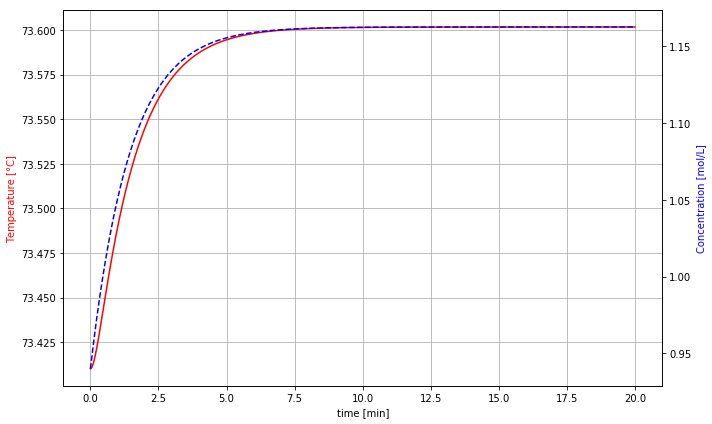

In [5]:
# Reload the pre-compiled model as an FMU
sys = load_fmu(model_initial)

# Simulation options
opts = sys.simulate_options()
opts["CVode_options"]["atol"] = 1e-15
opts["CVode_options"]["rtol"] = 1e-10
opts["CVode_options"]["verbosity"] = 50
opts["result_handling"] = "memory"

# Configure a step test
t0 = 0
tf = 20
delta = 0.002
pts = int((tf-t0)/delta)
t = np.linspace(t0, tf, pts)
opts["ncp"] = pts

# Set the system to the nominal operation point
sys.set(list(op.keys()), list(op.values()))

# Initialize the system in steady state for the given nominal operation point
sys.set(list(ss.keys()), list(ss.values()))

# Input the step
sys.set("Ci", 1.2)

# model response
res = sys.simulate(start_time=t0, final_time=tf, options = opts)

# Ploting the results
fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()
ax1.plot(res["time"], res["T"]-273.15, "r-", label="Outlet temperature of the reactant solution")
ax2.plot(res["time"], res["C"], "b--", label="Outlet concentration of the reactant")

ax1.set_xlabel("time [min]")
ax1.set_ylabel(u"Temperature [°C]", color="red")
ax2.set_ylabel("Concentration [mol/L]", color="blue")
ax1.grid(which="both")
plt.tight_layout()
plt.show()

plt.show()

# Run a continuous step test

In [6]:
from IPython import display

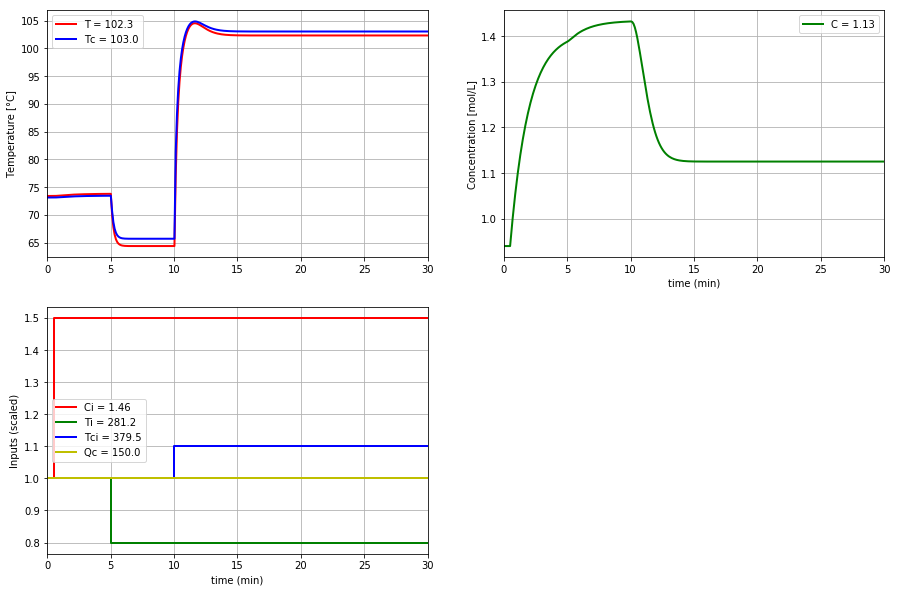

In [7]:
# Load a model instance into Python
sys = load_fmu(model_ss)

# Define the simulation options
opts = sys.simulate_options()
opts["CVode_options"]["atol"] = 1e-15
opts["CVode_options"]["rtol"] = 1e-10
opts["CVode_options"]["verbosity"] = 50
opts["result_handling"] = "memory"

# Reset and Initialize the system
sys.reset()

# Set the system to the nominal operation point
sys.set(list(op.keys()), list(op.values()))

sys.setup_experiment()
sys.initialize() # Initialize the system
opts["initialize"] = False # Continuous simulation

# Configure a step test
t0 = 0
tf = 30
delta = 0.1
pts = int((tf-t0)/delta)
t = np.linspace(t0, tf, pts)
opts["ncp"] = pts

# Arrays to store the inputs
Ci = np.ones(len(t))*op["Ci"]
Ti = np.ones(len(t))*op["Ti"]
Tci = np.ones(len(t))*op["Tci"]
Qc = np.ones(len(t))*op["Qc"]

# Step tests
Ci[5:] = 1.5*op["Ci"]
Ti[50:] = 0.8*op["Ti"]
Tci[100:] = 1.1*op["Tci"]

# Lists to store the simulation results
C = []
T = []
Tc = []

# Loop
for i in range(pts-1):
    # Insert the input values
    sys.set("Ci", Ci[i])
    sys.set("Ti", Ti[i])
    sys.set("Tci", Tci[i])
    sys.set("Qc", Qc[i])
    
    # set initial conditions for each step
    if i == 0:
        # we start at the steady state for the nominal condition
        var_names = [item.replace("0","") for item in ss.keys()]
        sys.set(var_names, list(ss.values()))
    else:
        # we use the value of the states from the previous step
        sys.set(list(state_values.keys()), list(state_values.values()))
    
    # Run simulator
    res = sys.simulate(start_time=(t[i]), final_time=(t[i+1]), options=opts)
    
    # Store the initial state value for the next cycle
    state_values = {
        "C": res["C"][-1],
        "T": res["T"][-1],
        "Tc": res["Tc"][-1]
    }
    
    # Get the results
    if i == 0: # Initial state values
        C.append(res["C"][0])
        T.append(res["T"][0]-273.15)
        Tc.append(res["Tc"][0]-273.15)
    
    C.append(res["C"][-1])
    T.append(res["T"][-1]-273.15)
    Tc.append(res["Tc"][-1]-273.15)
    
    # Plot
    plt.clf()
    plt.gca().cla()

    plt.subplot(221)
    plt.plot(t[0:(i+2)], T[0:(i+2)], "r-", lw=2, label="T = " + str(round(T[i+1], 1)))
    plt.plot(t[0:(i+2)], Tc[0:(i+2)], "b-", lw=2, label="Tc = " + str(round(Tc[i+1], 1)))
    plt.ylabel(u"Temperature [°C]")
    plt.legend(loc="best")
    plt.xlim(t[0], t[i+1])
    plt.grid(True)
        
    plt.subplot(222)
    plt.plot(t[0:(i+2)], C[0:(i+2)], "g-", lw=2, label="C = " + str(round(C[i+1], 2)))
    plt.ylabel("Concentration [mol/L]")
    plt.legend(loc="best")
    plt.xlim(t[0], t[i+1])
    plt.xlabel("time (min)")
    plt.grid(True)
    
    plt.subplot(223)
    plt.step(t[0:(i+2)], Ci[0:(i+2)]/op["Ci"], "r-", lw=2, where="post", label="Ci = " + str(round(Ci[i+1], 2)))
    plt.step(t[0:(i+2)], Ti[0:(i+2)]/op["Ti"], "g-", lw=2, where="post", label="Ti = " + str(round(Ti[i+1], 1)))
    plt.step(t[0:(i+2)], Tci[0:(i+2)]/op["Tci"], "b-", lw=2, where="post", label="Tci = " + str(round(Tci[i+1], 1)))
    plt.step(t[0:(i+2)], Qc[0:(i+2)]/op["Qc"], "y-", lw=2, where="post",label="Qc = " + str(round(Qc[i+1], 1)))
    plt.ylabel("Inputs (scaled)")
    plt.legend(loc="best")
    plt.xlim(t[0], t[i+1])
    plt.xlabel("time (min)")
    plt.grid(True)

    display.clear_output(wait=True)
    fig = plt.gcf()
    fig.set_size_inches(15,10)
    display.display(fig)
display.clear_output(wait=True)